In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyharm.io.kharma import KHARMAFile
from pyharm.io.phdf import phdf
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
from pyharm.grid import Grid

def plot_amr_levels_2d(filename, slice_dir='xy'):
    """绘制AMR网格细化级别的2D可视化图
    Args:
        filename: KHARMA输出文件路径
        slice_dir: 切片方向,'xy','xz'或'yz'
    """
    # 读取KHARMA文件和网格信息
    kf = KHARMAFile(filename)
    grid = Grid(kf.params)
    
    # 打开phdf文件获取MeshBlockSize
    fil = phdf(kf.fname)
    mesh_block_size = fil.MeshBlockSize
    
    # 获取基本参数
    num_blocks = kf.params['num_blocks']
    block_bounds = kf.params['phdf_aux']['BlockBounds']
    dx = kf.params['dx1']
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # 自定义颜色映射
    colors = ['#2C3E50', '#E74C3C', '#F1C40F', '#2ECC71', '#3498DB']
    n_bins = 5
    cmap = LinearSegmentedColormap.from_list("custom", colors, N=n_bins)
    
    # 记录坐标范围
    x_min, x_max = float('inf'), float('-inf')
    y_min, y_max = float('inf'), float('-inf')
    
    # 为每个块画出矩形
    levels = []
    for ib in range(num_blocks):
        bb = block_bounds[ib]
        block_dx = np.abs(bb[1] - bb[0])/mesh_block_size[0]
        level = int(round(dx / block_dx))
        levels.append(level)
        
        # 获取块的角点坐标
        if slice_dir == 'xy':
            # 转换到笛卡尔坐标
            r1, th1 = bb[0], bb[2]
            r2, th2 = bb[1], bb[3]
            x1, y1 = r1 * np.cos(th1), r1 * np.sin(th1)
            x2, y2 = r2 * np.cos(th1), r2 * np.sin(th1)
            x3, y3 = r2 * np.cos(th2), r2 * np.sin(th2)
            x4, y4 = r1 * np.cos(th2), r1 * np.sin(th2)
            
            # 创建多边形顶点
            xy = np.array([[x1,y1], [x2,y2], [x3,y3], [x4,y4]])
            polygon = plt.Polygon(xy, 
                                facecolor=cmap(level/max(levels)),
                                edgecolor='black',
                                linewidth=0.5,
                                alpha=0.7)
            ax.add_patch(polygon)
            
            # 更新坐标范围
            x_min = min(x_min, min(x1,x2,x3,x4))
            x_max = max(x_max, max(x1,x2,x3,x4))
            y_min = min(y_min, min(y1,y2,y3,y4))
            y_max = max(y_max, max(y1,y2,y3,y4))
    
    # 设置坐标轴
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    # 添加颜色条
    norm = plt.Normalize(min(levels), max(levels))
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm)
    cbar.set_label('AMR Level', fontsize=12)
    
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    plt.title('AMR Level Distribution', fontsize=14)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()
    
    fil.fid.close()

/tmp/ipykernel_3292448/373159829.py:80: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


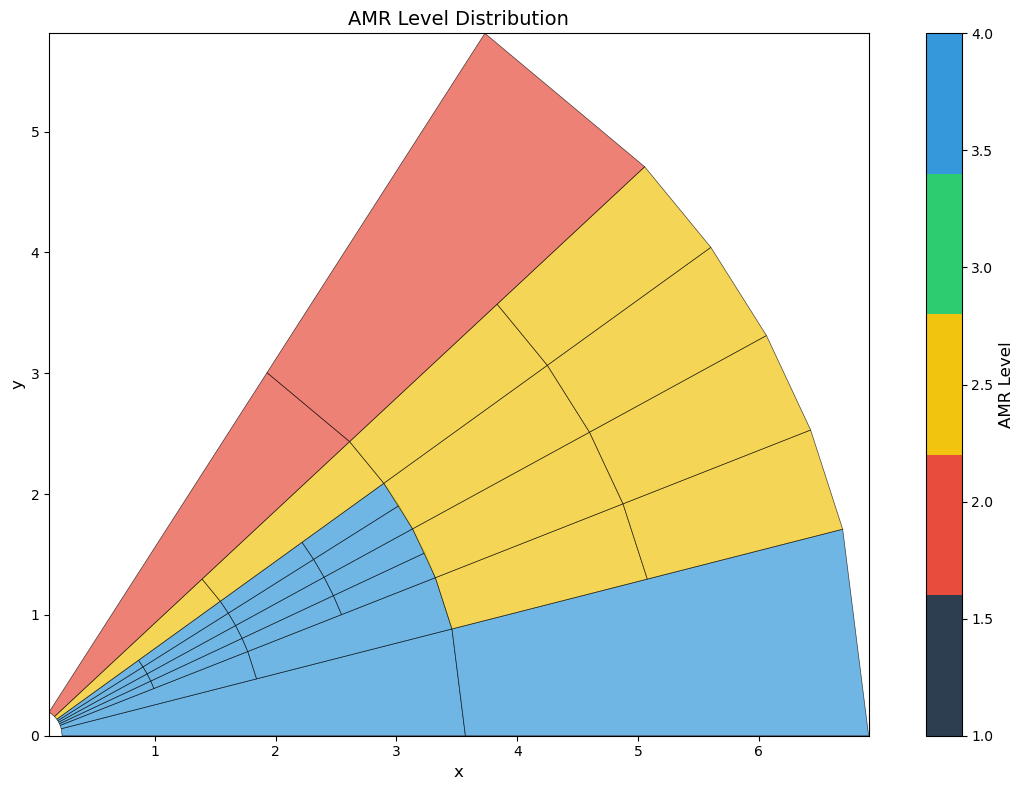

In [2]:
plot_amr_levels_2d("/home/zhangzelin/projects/kharma/output/20241202_hip_sane_a09375_512-512-1_smr-2_6-12_rout1000_min020_gamma13/torus.out0.00000.phdf", slice_dir='xy')

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pyharm
import pyharm.plots.plot_dumps as pplt

# Suppress warnings, to avoid math warnings for /0 or sqrt(-)
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

In [2]:
dump = pyharm.load_dump("/home/zhangzelin/projects/kharma/output/20241202_hip_sane_a09375_512-512-1_smr-2_6-12_rout1000_min020_gamma13/torus.out0.00000.phdf")


In [5]:
dump['phdf_aux']['BlockBounds']
dump['phdf_aux']['MeshBlockSize']
dump['phdf_aux']['BlockLevel']

array([1, 1, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4,
       4, 4, 2, 2, 2, 2, 2, 2, 1, 1])

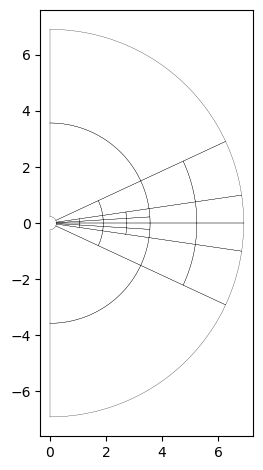

In [12]:
fig, ax = plt.subplots(1,1)
# pplt.plot_xz(ax, dump, 'log_rho', vmin=-4, vmax=1.5, window=(-20,20,-20,20), half_cut=True)
pplt.overlay_blocks(ax, dump, log_r=True)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()
# pplt.overlay_grid(ax, dump)
